<a href="https://colab.research.google.com/github/Fyaer/Data-Vis-Group-3-code/blob/main/Wong_Jimmy_Hw5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [3920] Homework 5 - Multi-model
Data file: https://raw.githubusercontent.com/vjavaly/Baruch-CIS-3920/main/data/liver_cirrhosis_stage_10K.csv

## Homework Submission Rules (for all homework assignments)
* Homework is due by 2:30 PM on the due date
  * No late submission will be accepted
* You must submit a cleanly executed notebook (*.ipynb)
  * Verify that you are submitting the correct homework file
* Homework file naming convention
  * LastName_FirstName_HwX.ipynb  [Replace X with the homework #]
    * 1 point deducted for submitting homework not complying with naming convention
* Before submission, execute "Kernel -> Restart Kernel and Run All Cells"
  * 1 point deducted for not submitting a cleanly executed notebook

## Homework 5 Requirements
* Load data
  * Do NOT use meaningless columns (e.g. 'Patient_ID') as independent variables
* Examine data
  * Display (e.g. bar chart) class distribution of target variable (Disease_Stage)
* Prepare data for model training
  * Perform the following data preparation steps
    * Handle missing values
    * Variable encoding
    * Feature scaling
  * Do not delete any rows
  * Do not drop any columns, EXCEPT when performing variable encoding
* Display a sample of 20 rows of the final set of independent variables used for all the model trainings
* Train logistic regression model
  * Must modify at least 2 hyperparameters (not including random_state)
    * The hyperparameter values you set CANNOT be the same as the defaults
    * You can modify as many hyperparameters as your want
  * Calculate and display model accuracy
* Train the following classification models (KNN, Random Forest & SVC).  For the SVC model, you can use any SVC classifier.  Perform the following for each model:
  * Must modify at least 2 hyperparameters (not including random_state) in each model
    * You can modify as many hyperparameters as desired
      * **NOTE: The objective of changing these hyperparameters is for each model's accuracy to exceed 80%**
      * The hyperparameter values you set CANNOT be the same as the default value
    * If you used hyperparameter random_state in your Logistic Regression model training, use the same value when training the other models
    * Do NOT re-split training and test sets when training the other models
  * Calculate and display this model's accuracy
    * **NOTE: For each of these 3 classification models, model accuracy MUST exceed 80%**
* Display (e.g. bar chart) model accuracy for all 4 models

#### NOTES
- You must TRY to resolve all errors and warnings
- You may set random_state hyperparameter to control the accuracy output

In [ ]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 12/13/24 19:48:39


### Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from pprint import pprint



# Add other imports as needed


### Load data

Liver Cirrhosis Stage Classification

Context
> Cirrhosis results from prolonged liver damage, leading to extensive scarring, often due to conditions like hepatitis or chronic alcohol consumption.

Data source
> Mayo Clinic study on primary biliary cirrhosis (PBC) of the liver carried out from 1974 to 1984.

> **NOTE: The professor has modified this dataset for the purposes of this assignment.  You must use this modified dataset for this homework.**

Features
* N_Days : # days between registration and the earlier of death, transplantation, or study analysis time in 1986
* Status : patient status - values = C (censored), CL (censored due to liver tx), or D (death)
* Drug : type of drug given (D-penicillamine) or placebo
* Age : patient age (days)
* Gender : M (male) or F (female)
* Ascites : presence of ascites N (No) or Y (Yes)
* Hepatomegaly : presence of hepatomegaly N (No) or Y (Yes)
* Spiders : presence of spiders N (No) or Y (Yes)
* Edema : presence of edema N (no edema and no diuretic therapy for edema), S (edema present without diuretics, or edema resolved by diuretics), or Y (edema despite diuretic therapy)
* Bilirubin : serum bilirubin in [mg/dl]
* Cholesterol : serum cholesterol in [mg/dl]
* Albumin : albumin in [gm/dl]
* Copper : urine copper in [ug/day]
* Alk_Phos : alkaline phosphatase in [U/liter]
* SGOT : serum glutamic-oxaloacetic transaminase, an enzyme level indicating liver health in [U/ml]
* Tryglicerides : triglicerides in [mg/dl]
* Platelets : platelets per cubic [ml/1000]
* Prothrombin : prothrombin time in seconds [s]
* Patient_ID : patient ID

Target variable to predict:
* Disease_Stage: stage_1, stage_2, stage_3

In [ ]:
# Read data from file (liver_cirrhosis_stage_10K.csv) into dataframe
#  NOTES:
#   Field separator is ';'
#   Use column 'Patient_ID' as index_col

df= pd.read_csv('https://raw.githubusercontent.com/vjavaly/Baruch-CIS-3920/main/data/liver_cirrhosis_stage_10K.csv', sep=';', index_col='Patient_ID')


### Examine data

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
# Review dataframe shape
df.shape

(10000, 19)

In [ ]:
# Display a sample of 5 rows from dataframe
df.sample(5)

,N_Days,Status,Drug,Age,Gender,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Disease_Stage
Patient_ID,,,,,,,,,,,,,,,,,,,
24547,877.0,CL,D-penicillamine,12912.0,M,N,N,N,N,2.4,646.000000,3.83,102.000000,855.000000,127.000000,194.000000,306.0,10.3,stage_2
11264,2576.0,C,Placebo,16463.0,F,N,N,N,N,0.5,316.000000,3.65,68.000000,1716.000000,187.550000,71.000000,269.0,9.7,stage_2
23966,1302.0,C,D-penicillamine,22111.0,M,N,Y,N,N,6.6,1000.000000,3.07,88.000000,3150.000000,193.000000,133.000000,299.0,10.9,stage_3
18631,2534.0,C,D-penicillamine,13616.0,F,N,N,N,S,0.8,369.510563,3.89,97.648387,1982.655769,122.556346,124.702128,447.0,10.7,stage_2
9598,853.0,D,D-penicillamine,14212.0,F,N,Y,Y,N,25.5,358.000000,3.52,219.000000,2468.000000,201.500000,205.000000,141.0,10.9,stage_2


### Display bar chart showing class distribution for target variable (Disease_Stage)

In [ ]:
# Display class distribution counts
df['Disease_Stage'].value_counts()

,count
Disease_Stage,
stage_2,3416
stage_1,3307
stage_3,3277


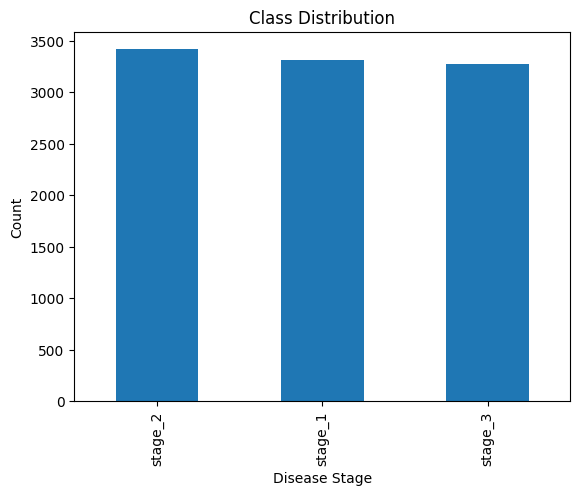

In [ ]:
# Display bar chart showing class distribution
df['Disease_Stage'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Disease Stage')
plt.ylabel('Count')
plt.show()

### Prepare data for model training
* Do not delete any rows
* Do not drop any columns, EXCEPT when performing variable encoding

#### Check for missing values

In [ ]:
df.isnull().sum()

,0
N_Days,18
Status,107
Drug,0
Age,25
Gender,44
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0
Bilirubin,0


#### Use the SimpleImputer to replace missing values

In [ ]:
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
cols_to_impute = ['Gender' , 'Status']
df[cols_to_impute] = imp.fit_transform(df[cols_to_impute])

In [ ]:
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
cols_to_impute = ['Age' , 'N_Days']
df[cols_to_impute] = imp.fit_transform(df[cols_to_impute])

#### Check for missing values again

In [ ]:
df.isnull().sum()

,0
N_Days,0
Status,0
Drug,0
Age,0
Gender,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0
Bilirubin,0


### Perform one-hot encoding

In [ ]:
df = pd.get_dummies(df, columns= ['Gender', 'Ascites'], dtype=int)

In [ ]:
df = pd.get_dummies(df, columns=['Hepatomegaly','Spiders'], dtype=int)

In [ ]:
df = pd.get_dummies(df, columns=['Edema', 'Status'], dtype=int)

### Perform label encoding

In [ ]:
le = LabelEncoder()
df['Drug']= le.fit_transform(df['Drug'])


In [ ]:
df

,N_Days,Drug,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Disease_Stage,Gender_F,Gender_M,Ascites_N,Ascites_Y,Hepatomegaly_N,Hepatomegaly_Y,Spiders_N,Spiders_Y,Edema_N,Edema_S,Edema_Y,Status_C,Status_CL,Status_D
Patient_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,
10481,2772.0,1,16071.0,0.6,217.000000,3.62,13.000000,414.000000,75.950000,119.000000,292.00000,10.2,stage_2,0,1,0,1,1,0,0,1,1,0,0,1,0,0
19109,1234.0,1,21185.0,6.4,373.000000,3.46,155.000000,1768.000000,120.000000,151.000000,109.00000,10.4,stage_3,1,0,0,1,1,0,0,1,1,0,0,1,0,0
14801,1349.0,0,12285.0,2.2,572.000000,3.77,77.000000,2520.000000,92.000000,114.000000,226.00000,11.7,stage_3,1,0,1,0,0,1,1,0,1,0,0,1,0,0
22491,4196.0,1,17841.0,1.2,258.000000,3.57,79.000000,2201.000000,120.900000,76.000000,410.00000,11.5,stage_3,1,0,1,0,0,1,1,0,1,0,0,1,0,0
8594,2443.0,1,16050.0,0.9,308.000000,3.69,67.000000,696.000000,51.150000,101.000000,278.00000,9.9,stage_3,1,0,1,0,0,1,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,994.0,1,17703.0,0.4,260.000000,2.75,41.000000,1166.000000,70.000000,82.000000,172.00000,10.5,stage_1,0,1,1,0,1,0,1,0,1,0,0,1,0,0
22218,1072.0,1,14245.0,1.5,369.510563,3.81,97.648387,1982.655769,122.556346,124.702128,255.00000,10.8,stage_2,1,0,0,1,1,0,0,1,1,0,0,1,0,0
19024,1616.0,1,27394.0,2.2,369.510563,3.26,97.648387,1982.655769,122.556346,124.702128,257.02457,11.8,stage_3,1,0,0,1,1,0,0,1,0,1,0,0,0,1


### Separate independent and dependent variables
* Independent variables: All variables EXCEPT Disease_Stage
* Dependent variable: Disease_Stage

In [ ]:
X = df.drop('Disease_Stage', axis = 1)
y = df['Disease_Stage']

#### Standardize the data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Display a sample of 20 rows of the final set of independent variables used for all the model trainings

In [ ]:
df.sample(20)

,N_Days,Drug,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Disease_Stage,Gender_F,Gender_M,Ascites_N,Ascites_Y,Hepatomegaly_N,Hepatomegaly_Y,Spiders_N,Spiders_Y,Edema_N,Edema_S,Edema_Y,Status_C,Status_CL,Status_D
Patient_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,
10714,2666.0,0,20233.0,0.6,220.000000,3.35,57.000000,1620.000000,153.450000,80.000000,149.0,11.0,stage_3,1,0,0,1,0,1,1,0,0,1,0,1,0,0
3524,1301.0,0,20834.0,1.1,432.000000,3.57,45.000000,1406.000000,190.000000,77.000000,117.0,11.6,stage_3,1,0,1,0,0,1,0,1,0,1,0,0,1,0
6253,43.0,1,16802.0,13.8,369.510563,2.77,97.648387,1982.655769,122.556346,124.702128,219.0,11.5,stage_3,1,0,0,1,1,0,0,1,1,0,0,1,0,0
4509,3030.0,1,22646.0,0.8,369.510563,2.48,97.648387,1982.655769,122.556346,124.702128,274.0,10.0,stage_1,1,0,0,1,1,0,0,1,1,0,0,1,0,0
8788,3150.0,1,15628.0,0.4,263.000000,3.57,123.000000,836.000000,74.400000,121.000000,231.0,9.5,stage_2,1,0,1,0,0,1,1,0,1,0,0,1,0,0
1994,2555.0,1,13535.0,0.6,369.510563,3.69,161.000000,674.000000,26.350000,124.702128,166.0,9.9,stage_1,1,0,1,0,0,1,1,0,1,0,0,1,0,0
13706,3358.0,1,25329.0,2.1,262.000000,3.48,58.000000,2045.000000,89.900000,84.000000,236.0,9.9,stage_2,1,0,1,0,0,1,1,0,1,0,0,0,0,1
6661,4427.0,0,24621.0,1.9,259.000000,3.70,281.000000,10396.800000,188.340000,178.000000,214.0,11.0,stage_2,1,0,1,0,1,0,1,0,1,0,0,1,0,0
2088,3992.0,1,15712.0,1.2,256.000000,3.60,74.000000,724.000000,141.050000,108.000000,349.0,11.1,stage_1,1,0,1,0,1,0,1,0,1,0,0,1,0,0


### Display a sample of 5 rows of the final set of dependent variables used for all the model trainings

In [ ]:
y.sample(5)

,Disease_Stage
Patient_ID,
8929,stage_1
1121,stage_2
6851,stage_2
2693,stage_3
10840,stage_3


### Split data into training and test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,stratify=y, test_size = 0.3,  random_state=42)

### Train Logistic Regression model
#### Must modify at least 2 hyperparameters (excluding random_state)

In [ ]:
logreg = LogisticRegression(max_iter=1000 , solver = 'liblinear', random_state = 42)
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

### Evaluate Logistic Regression model

In [ ]:
predictions = logreg.predict(X_test)
accuracy = logreg.score(X_test, y_test)
print("accuracy =", round((accuracy * 100), 2), "%")

accuracy = 56.83 %


### Train KNN classifier model
#### Must modify at least 2 hyperparameters (excluding random_state)

In [ ]:
Knn = KNeighborsClassifier(n_neighbors = 5 , weights = 'distance' , metric = 'euclidean' )
Knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', weights='distance')

### Evaluate KNN model

In [ ]:
predictions2 = Knn.predict(X_test)
accuracy2 = Knn.score(X_test, y_test)
print("accuracy =", round((accuracy2 * 100), 2), "%")

accuracy = 82.03 %


### Train Random Forest classifier model
#### Must modify at least 2 hyperparameters (excluding random_state)

In [ ]:
rf = RandomForestClassifier()
rf.get_params()

rf = RandomForestClassifier(max_features = 'log2', n_estimators= 1000 , random_state = 42 )
rf.fit(X_train, y_train)

RandomForestClassifier(max_features='log2', n_estimators=1000, random_state=42)

### Evaluate Random Forest model

In [ ]:
predictions3 = rf.predict(X_test)
accuracy3 = rf.score(X_test, y_test)
print("accuracy =", round((accuracy3 * 100), 2), "%")

accuracy = 92.9 %


### Train Support Vector Classifier model
#### Must modify at least 2 hyperparameters (excluding random_state)

In [ ]:
svc_model =  SVC( gamma = 0.0001 , C = 10 , kernel = 'rbf' )
svc_model.fit(X_train, y_train)

SVC(C=10, gamma=0.0001)

### Evaluate Support Vector Classifier model

In [ ]:
predictions4 = svc_model.predict(X_test)
accuracy4 = svc_model.score(X_test, y_test)
print("accuracy =", round((accuracy4 * 100), 2), "%")

accuracy = 77.6 %


### Display bar chart comparison of accuracy for all 4 models

In [ ]:
Scores  = pd.Series({'Logistic Regression': accuracy, 'KNN': accuracy2, 'Random Forest': accuracy3, 'SVC': accuracy4})





Scores.plot(kind='bar')
plt.title('Scores')
plt.xlabel('Model')
plt.ylabel('accuracy')
plt.show()